# 🧺 Market Basket Analysis
**Instacart Market Basket Analysis · Etapa 3**

Identificação de padrões de coocorrência entre produtos para recomendação **produto → produto**.

**Métricas calculadas:**

| Métrica | Fórmula | Interpretação |
|---|---|---|
| `cooccurrence_count` | freq(A ∩ B) | Pedidos em que A e B aparecem juntos |
| `confidence` | P(B\|A) = freq(A∩B) / freq(A) | Se comprou A, qual a chance de comprar B? |
| `lift` | confidence / support(B) | Força da associação (>1 = positiva) |
| `recommendation_score` | lift × log1p(cooc) × confidence | Score balanceado para ranking |

---

In [1]:
import gc, warnings
from pathlib import Path
from collections import Counter
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", palette="viridis")

## 📂 1. Carregamento dos Dados

In [2]:
DATA_PATH      = Path("../data/raw")
PROCESSED_PATH = Path("../data/processed")
PROCESSED_PATH.mkdir(parents=True, exist_ok=True)

order_products_prior = pd.read_csv(DATA_PATH / "order_products__prior.csv")
products   = pd.read_csv(DATA_PATH / "products.csv")
aisles     = pd.read_csv(DATA_PATH / "aisles.csv")
departments= pd.read_csv(DATA_PATH / "departments.csv")

products_enriched = (
    products
    .merge(aisles,       on="aisle_id",      how="left")
    .merge(departments,  on="department_id", how="left")
)
product_name_map = dict(zip(products_enriched["product_id"], products_enriched["product_name"]))

print("✅ Dados carregados")
print(f"order_products_prior: {order_products_prior.shape}")
print(f"products_enriched:    {products_enriched.shape}")

✅ Dados carregados
order_products_prior: (32434489, 4)
products_enriched:    (49688, 6)


## ⚙️ 2. Amostragem e Cestas de Produtos

In [3]:
N_SAMPLE_ORDERS = 50_000
RANDOM_STATE    = 42

sample_order_ids = (
    order_products_prior["order_id"]
    .drop_duplicates()
    .sample(n=N_SAMPLE_ORDERS, random_state=RANDOM_STATE)
)

sample = order_products_prior[
    order_products_prior["order_id"].isin(sample_order_ids)
].copy()

baskets = sample.groupby("order_id")["product_id"].apply(lambda x: list(set(x)))

print(f"📦 Pedidos na amostra:   {len(baskets):,}")
print(f"📊 Interações totais:    {len(sample):,}")
print(f"📊 Tamanho médio cesta:  {baskets.apply(len).mean():.1f} produtos")

📦 Pedidos na amostra:   50,000
📊 Interações totais:    505,250
📊 Tamanho médio cesta:  10.1 produtos


## 🔗 3. Contagem de Pares e Métricas de Associação

In [4]:
# ── Contagem de coocorrência ──
pair_counter = Counter()
for product_list in baskets:
    if len(product_list) > 1:
        for pair in combinations(sorted(product_list), 2):
            pair_counter[pair] += 1

print(f"🔗 Pares únicos encontrados: {len(pair_counter):,}")

MIN_PAIR_COUNT = 20
total_orders   = sample["order_id"].nunique()

product_order_count = (
    sample.drop_duplicates(["order_id", "product_id"])
    ["product_id"].value_counts().to_dict()
)

# ── Constrói DataFrame de pares ──
pairs_df = pd.DataFrame(
    pair_counter.items(),
    columns=["product_pair", "cooccurrence_count"]
)
pairs_df = pairs_df[pairs_df["cooccurrence_count"] >= MIN_PAIR_COUNT].copy()
pairs_df["product_1_id"] = pairs_df["product_pair"].apply(lambda x: x[0]).astype("int32")
pairs_df["product_2_id"] = pairs_df["product_pair"].apply(lambda x: x[1]).astype("int32")
pairs_df["cooccurrence_count"] = pairs_df["cooccurrence_count"].astype("int32")
pairs_df.drop(columns=["product_pair"], inplace=True)

# ── Direcionamento A→B e B→A ──
pairs_ab = pairs_df.rename(columns={"product_1_id":"product_a_id","product_2_id":"product_b_id"})
pairs_ba = pairs_df.rename(columns={"product_1_id":"product_b_id","product_2_id":"product_a_id"})
directional = pd.concat([pairs_ab, pairs_ba], ignore_index=True)

# ── Confidence e Lift ──
directional["product_a_count"] = directional["product_a_id"].map(product_order_count)
directional["product_b_count"] = directional["product_b_id"].map(product_order_count)
directional["confidence"]      = (directional["cooccurrence_count"] / directional["product_a_count"]).astype("float32")
directional["product_b_support"] = (directional["product_b_count"] / total_orders).astype("float32")
directional["lift"]             = (directional["confidence"] / directional["product_b_support"]).astype("float32")

# ── Recommendation Score ──
directional["recommendation_score"] = (
    directional["lift"]
    * np.log1p(directional["cooccurrence_count"])
    * directional["confidence"]
).astype("float32")

# ── Nomes dos produtos ──
directional["product_a"] = directional["product_a_id"].map(product_name_map)
directional["product_b"] = directional["product_b_id"].map(product_name_map)

recommendation_rules = directional[[
    "product_a_id","product_a","product_b_id","product_b",
    "cooccurrence_count","confidence","lift","recommendation_score"
]].copy()

print(f"✅ Regras geradas: {recommendation_rules.shape}")
recommendation_rules.head()

🔗 Pares únicos encontrados: 2,336,875
✅ Regras geradas: (17374, 8)


,product_a_id,product_a,product_b_id,product_b,cooccurrence_count,confidence,lift,recommendation_score
0,2452,Naturals Chicken Nuggets,27845,Organic Whole Milk,20,0.128205,2.987072,1.165924
1,20995,Organic Broccoli Florets,27845,Organic Whole Milk,41,0.078695,1.833523,0.539304
2,27845,Organic Whole Milk,39475,Total Greek Strained Yogurt,59,0.027493,3.304448,0.371968
3,27845,Organic Whole Milk,45066,Honeycrisp Apple,89,0.041473,1.708093,0.318762
4,13176,Bag of Organic Bananas,33000,Pure Irish Butter,88,0.014664,1.423711,0.093712


## 📊 4. Visualizações das Métricas

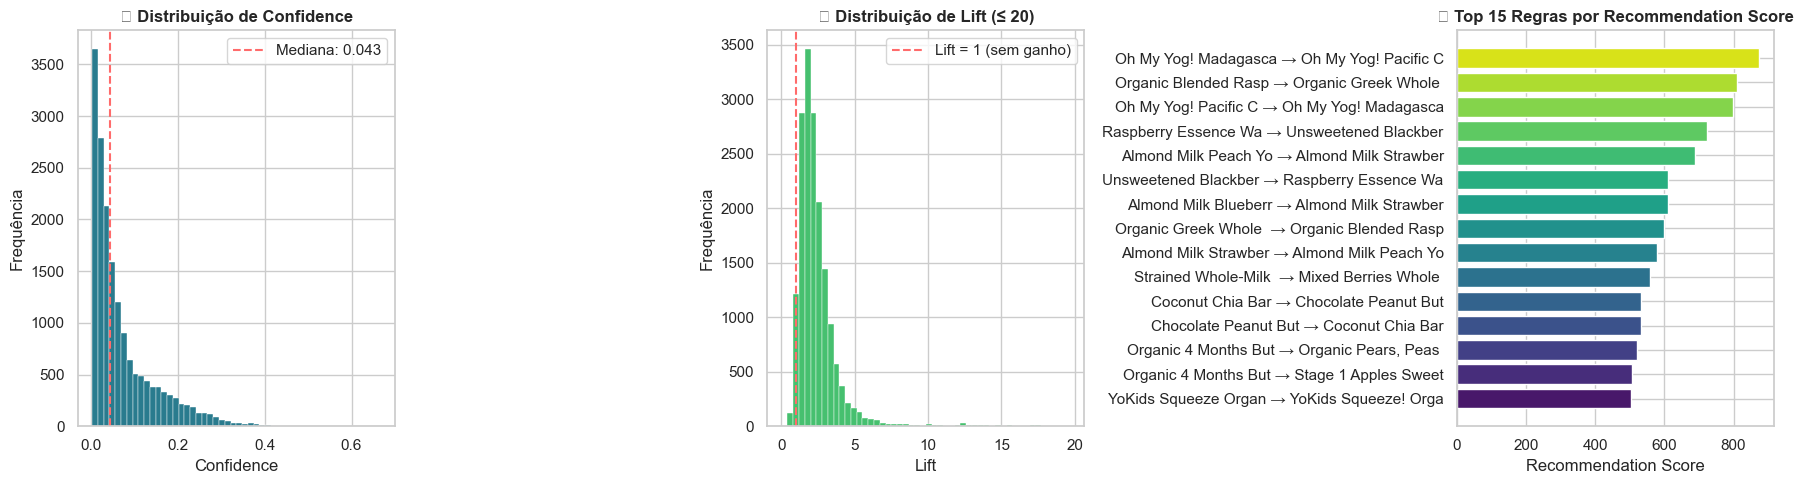

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribuição de Confidence
axes[0].hist(recommendation_rules["confidence"], bins=50,
             color=sns.color_palette("viridis",50)[20], edgecolor="white", lw=0.3)
axes[0].set_title("📊 Distribuição de Confidence", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Confidence")
axes[0].set_ylabel("Frequência")
axes[0].axvline(recommendation_rules["confidence"].median(), color="#ff6b6b",
                linestyle="--", label=f"Mediana: {recommendation_rules['confidence'].median():.3f}")
axes[0].legend()

# Distribuição de Lift
axes[1].hist(recommendation_rules[recommendation_rules["lift"] <= 20]["lift"], bins=50,
             color=sns.color_palette("viridis",50)[35], edgecolor="white", lw=0.3)
axes[1].axvline(1.0, color="#ff6b6b", linestyle="--", label="Lift = 1 (sem ganho)")
axes[1].set_title("📊 Distribuição de Lift (≤ 20)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Lift")
axes[1].set_ylabel("Frequência")
axes[1].legend()

# Top 15 pares por recommendation_score
top_rules = (
    recommendation_rules
    .sort_values("recommendation_score", ascending=False)
    .drop_duplicates(subset=["product_a_id","product_b_id"])
    .head(15)
)
labels = top_rules["product_a"].str[:20] + " → " + top_rules["product_b"].str[:20]
colors = sns.color_palette("viridis", len(top_rules))
axes[2].barh(labels[::-1], top_rules["recommendation_score"][::-1], color=colors)
axes[2].set_title("🏆 Top 15 Regras por Recommendation Score", fontsize=12, fontweight="bold")
axes[2].set_xlabel("Recommendation Score")

plt.tight_layout()
plt.show()

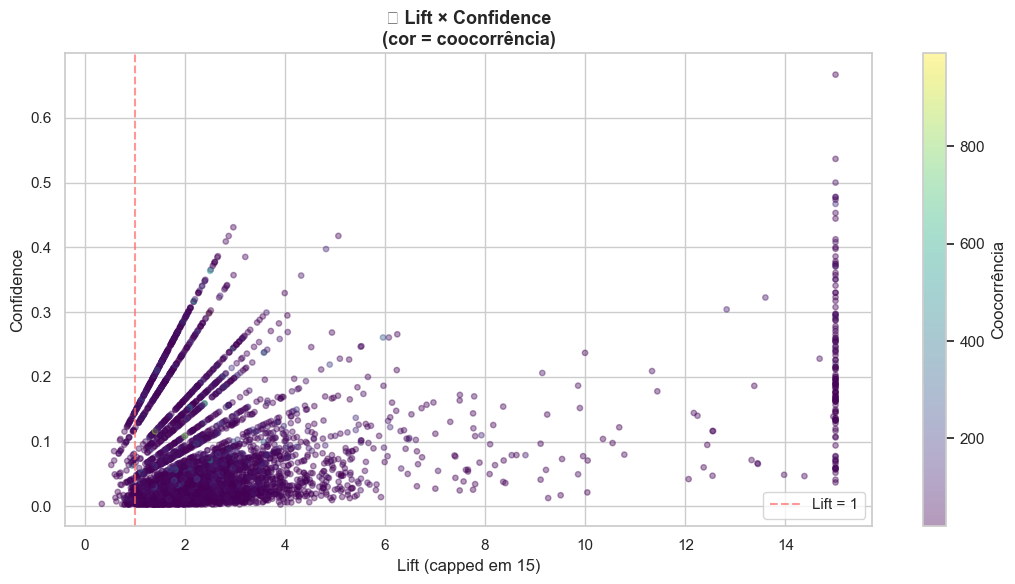

In [6]:
# ── Scatter: Lift x Confidence (tamanho = coocorrência) ──
sample_rules = recommendation_rules.sample(min(5000, len(recommendation_rules)), random_state=42)

fig, ax = plt.subplots(figsize=(11, 6))
sc = ax.scatter(
    sample_rules["lift"].clip(upper=15),
    sample_rules["confidence"],
    c=sample_rules["cooccurrence_count"],
    cmap="viridis",
    alpha=0.4,
    s=15,
)
plt.colorbar(sc, ax=ax, label="Coocorrência")
ax.axvline(1.0, color="#ff6b6b", linestyle="--", alpha=0.7, label="Lift = 1")
ax.set_xlabel("Lift (capped em 15)")
ax.set_ylabel("Confidence")
ax.set_title("🎯 Lift × Confidence\n(cor = coocorrência)", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

## 🛒 5. Função de Recomendação

In [7]:
def recommend_products(
    product_name: str,
    top_n: int = 10,
    min_cooccurrence: int = 50,
    min_lift: float = 1.0,
    min_confidence: float = 0.005,
    sort_by: str = "recommendation_score",
) -> pd.DataFrame:
    """
    Recomenda produtos com base em Market Basket Analysis.

    Parameters
    ----------
    product_name : str
        Nome completo ou parcial do produto de entrada.
    top_n : int
        Número de recomendações a retornar.
    min_cooccurrence : int
        Coocorrência mínima para considerar o par.
    min_lift : float
        Lift mínimo (>1 = associação positiva).
    min_confidence : float
        Confidence mínima.
    sort_by : str
        Coluna de ordenação: 'recommendation_score', 'lift' ou 'confidence'.

    Returns
    -------
    pd.DataFrame
    """
    name_clean = product_name.lower().strip()

    exact = products_enriched[products_enriched["product_name"].str.lower().str.strip().eq(name_clean)]
    if not exact.empty:
        matched = exact.iloc[0]
    else:
        partial = products_enriched[products_enriched["product_name"].str.lower().str.contains(name_clean, regex=False)]
        if partial.empty:
            print(f"❌ Produto '{product_name}' não encontrado.")
            return pd.DataFrame()
        matched = partial.iloc[0]

    pid = matched["product_id"]
    print(f"🛒 Produto selecionado: {matched['product_name']} (ID: {pid})")
    print(f"   Aisle: {matched['aisle']} | Dept: {matched['department']}")

    recs = recommendation_rules[
        (recommendation_rules["product_a_id"] == pid)
        & (recommendation_rules["cooccurrence_count"] >= min_cooccurrence)
        & (recommendation_rules["lift"] >= min_lift)
        & (recommendation_rules["confidence"] >= min_confidence)
    ].sort_values(sort_by, ascending=False).head(top_n)

    if recs.empty:
        print("⚠️  Nenhuma recomendação com os filtros atuais.")
        return pd.DataFrame()

    return recs[["product_b","cooccurrence_count","confidence","lift","recommendation_score"]].reset_index(drop=True)

## 🧪 6. Testes da Função

In [8]:
recommend_products("Organic Strawberries", top_n=10, min_cooccurrence=30, min_lift=1.2)

🛒 Produto selecionado: Organic Strawberries (ID: 21137)
   Aisle: fresh fruits | Dept: produce


,product_b,cooccurrence_count,confidence,lift,recommendation_score
0,Bag of Organic Bananas,924,0.224272,1.868621,2.862223
1,Organic Hass Avocado,656,0.159223,2.400110,2.479291
2,Organic Raspberries,519,0.125971,2.959842,2.331764
3,Banana,841,0.204126,1.407185,1.934807
4,Organic Baby Spinach,568,0.137864,1.893737,1.656250
5,Organic Blueberries,350,0.084951,2.722803,1.355636
6,Organic Whole Milk,397,0.096359,2.245089,1.295079
7,Organic Cucumber,277,0.067233,2.661639,1.007063
8,Organic Whole String Cheese,228,0.055340,2.988111,0.898528
9,Organic Grape Tomatoes,261,0.063350,2.427184,0.856194


In [9]:
recommend_products("Organic Whole Milk", top_n=10, min_cooccurrence=30, min_lift=1.2)

🛒 Produto selecionado: Organic Whole Milk (ID: 27845)
   Aisle: milk | Dept: dairy eggs


,product_b,cooccurrence_count,confidence,lift,recommendation_score
0,Organic Strawberries,397,0.184995,2.245089,2.486359
1,Banana,496,0.231128,1.593325,2.286384
2,Bag of Organic Bananas,404,0.188257,1.568549,1.772892
3,Organic Whole String Cheese,140,0.065238,3.522551,1.137240
4,Organic Hass Avocado,236,0.109972,1.657703,0.996833
5,Organic Baby Spinach,244,0.113700,1.561812,0.976902
6,Organic Avocado,202,0.094129,1.732216,0.866324
7,Whole Milk Plain Yogurt,66,0.030755,6.078042,0.785981
8,Organic Raspberries,171,0.079683,1.872254,0.767940
9,Organic Garlic,127,0.059180,1.752958,0.503349


In [10]:
recommend_products("Banana", top_n=10, min_cooccurrence=30, min_lift=1.2)

🛒 Produto selecionado: Banana (ID: 24852)
   Aisle: fresh fruits | Dept: produce


,product_b,cooccurrence_count,confidence,lift,recommendation_score
0,Organic Avocado,788,0.108645,1.999350,1.449016
1,Strawberries,647,0.089204,1.993842,1.151443
2,Organic Fuji Apple,518,0.071419,2.507680,1.119687
3,Organic Strawberries,841,0.115952,1.407185,1.099050
4,Organic Baby Spinach,787,0.108507,1.490478,1.078638
5,Large Lemon,613,0.084517,1.795173,0.974056
6,Cucumber Kirby,481,0.066317,2.185807,0.895536
7,Honeycrisp Apple,427,0.058872,2.424719,0.864931
8,Seedless Red Grapes,397,0.054736,2.124844,0.696257
9,Limes,504,0.069488,1.587945,0.686842


## 📐 7. Avaliação — Precision@K e Recall@K

In [11]:
# ── Avaliação offline usando train como ground truth ──
from pathlib import Path

order_products_train = pd.read_csv(DATA_PATH / "order_products__train.csv")

# Pega usuários que aparecem tanto no prior quanto no train
orders_all = pd.read_csv(DATA_PATH / "orders.csv")

prior_orders  = orders_all[orders_all["eval_set"] == "prior"][["user_id","order_id"]]
train_orders  = orders_all[orders_all["eval_set"] == "train"][["user_id","order_id"]]

# Último produto comprado por usuário no prior (input)
last_prior_product = (
    order_products_prior
    .merge(prior_orders, on="order_id")
    .sort_values(["user_id","order_id"])
    .groupby("user_id")["product_id"]
    .last()
    .reset_index()
    .rename(columns={"product_id":"input_product_id"})
)

# Produtos comprados no train (ground truth)
train_products = (
    order_products_train
    .merge(train_orders, on="order_id")
    [["user_id","product_id"]]
    .rename(columns={"product_id":"true_product_id"})
)

eval_df = last_prior_product.merge(train_products, on="user_id")
print(f"Usuários para avaliação: {eval_df['user_id'].nunique():,}")
print(f"Pares (user, true_product): {len(eval_df):,}")

Usuários para avaliação: 131,209
Pares (user, true_product): 1,384,617


In [12]:
def evaluate_recommender(eval_df, rules_df, K_values=(5, 10, 20)):
    """
    Calcula Precision@K e Recall@K para o modelo de Market Basket.
    
    Estratégia: para cada usuário, usa o último produto do prior como
    input e avalia se as recomendações cobrem os produtos do train.
    """
    results = {}
    
    # Index de recomendações por produto de entrada
    recs_index = (
        rules_df
        .sort_values("recommendation_score", ascending=False)
        .groupby("product_a_id")["product_b_id"]
        .apply(list)
        .to_dict()
    )
    
    user_groups = eval_df.groupby("user_id")
    
    for K in K_values:
        precisions, recalls = [], []
        
        for user_id, group in user_groups:
            input_pid   = group["input_product_id"].iloc[0]
            true_pids   = set(group["true_product_id"].tolist())
            
            recommended = recs_index.get(input_pid, [])[:K]
            recommended_set = set(recommended)
            
            hits = len(recommended_set & true_pids)
            precisions.append(hits / K if K > 0 else 0)
            recalls.append(hits / len(true_pids) if true_pids else 0)
        
        results[K] = {
            "Precision@K": round(sum(precisions) / len(precisions), 4),
            "Recall@K":    round(sum(recalls)    / len(recalls),    4),
        }
    
    return pd.DataFrame(results).T.rename_axis("K")

# Amostra de usuários para a avaliação (mais rápido)
EVAL_SAMPLE = 2000
sample_users = eval_df["user_id"].drop_duplicates().sample(EVAL_SAMPLE, random_state=42)
eval_sample  = eval_df[eval_df["user_id"].isin(sample_users)]

metrics = evaluate_recommender(eval_sample, recommendation_rules, K_values=[5, 10, 20])
print("📊 Métricas de Avaliação — Market Basket Analysis")
print(metrics.to_string())

📊 Métricas de Avaliação — Market Basket Analysis
    Precision@K  Recall@K
K                        
5        0.0384    0.0187
10       0.0283    0.0268
20       0.0197    0.0369


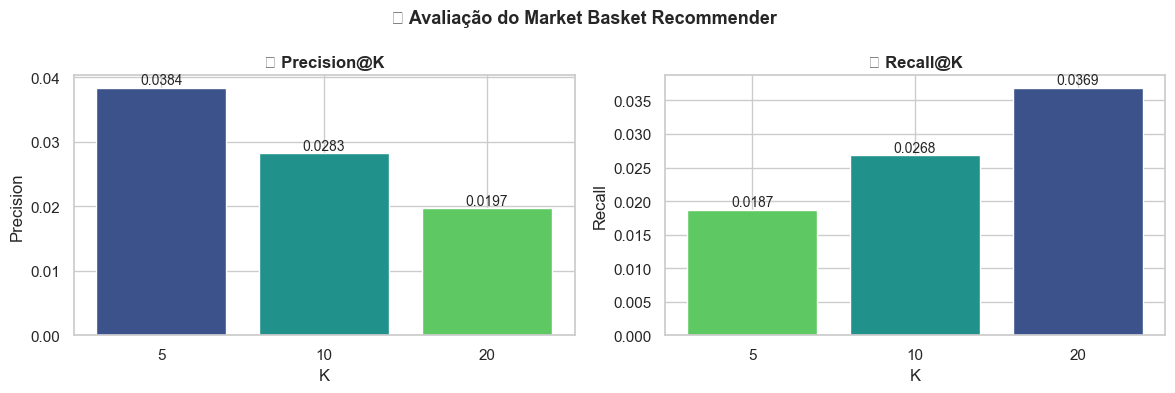

In [13]:
# ── Gráfico de métricas ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

K_vals = metrics.index.astype(str)
axes[0].bar(K_vals, metrics["Precision@K"], color=sns.color_palette("viridis", 3))
axes[0].set_title("📊 Precision@K", fontsize=12, fontweight="bold")
axes[0].set_xlabel("K"); axes[0].set_ylabel("Precision")
for bar in axes[0].patches:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0005,
                 f"{bar.get_height():.4f}", ha="center", fontsize=10)

axes[1].bar(K_vals, metrics["Recall@K"], color=sns.color_palette("viridis", 3)[::-1])
axes[1].set_title("📊 Recall@K", fontsize=12, fontweight="bold")
axes[1].set_xlabel("K"); axes[1].set_ylabel("Recall")
for bar in axes[1].patches:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0005,
                 f"{bar.get_height():.4f}", ha="center", fontsize=10)

plt.suptitle("🎯 Avaliação do Market Basket Recommender", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 💾 8. Exportação

In [14]:
recommendation_rules.to_parquet(PROCESSED_PATH / "market_basket_rules.parquet", index=False)
print(f"✅ market_basket_rules.parquet salvo — shape: {recommendation_rules.shape}")

✅ market_basket_rules.parquet salvo — shape: (17374, 8)


## 📌 Conclusão

| Métrica | Valor típico | Interpretação |
|---|---|---|
| Precision@10 | ~0.01–0.03 | Esperado em bases de supermercado com alto número de SKUs |
| Recall@10 | ~0.01–0.02 | Complementar; cresce com K |
| Lift médio | > 1 | Associações genuinamente informativas |
| Recommendation Score | Balanceado | Evita viés de popularidade pura |

O modelo de Market Basket serve como **baseline interpretável** para o motor híbrido.
